# 02 Analysis and Figure Generation

This notebook calculates rainfall climatology, annual and seasonal rainfall indices, trend summaries, and manuscript figures for the PAGASA Science Garden rainfall trend analysis.

This notebook uses the prepared daily dataset generated by `01_data_preparation.ipynb`.

Main outputs:

1. Monthly rainfall climatology and TC-proximity rainfall fractions.
2. Annual rainfall indices and trends.
3. November–April seasonal rainfall indices and trends.
4. May–October seasonal rainfall indices and trends.
5. Manuscript figures and tables.
6. Supplementary trend and sensitivity outputs.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
PROJECT_DIR = Path(".").resolve()

OUTPUT_DIR = PROJECT_DIR / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate"

SUPP_FIGURE_DIR = FIGURE_DIR / "supplementary"
SUPP_TABLE_DIR = TABLE_DIR / "supplementary"

for path in [FIGURE_DIR, TABLE_DIR, SUPP_FIGURE_DIR, SUPP_TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREPARED_PKL_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.pkl"
PREPARED_CSV_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.csv"

# Main manuscript figures
FIGURE_01_PATH = FIGURE_DIR / "figure_01_climatology.png"
FIGURE_02_PATH = FIGURE_DIR / "figure_02_annual_trends.png"
FIGURE_03_PATH = FIGURE_DIR / "figure_03_nov_apr_trends.png"
FIGURE_04_PATH = FIGURE_DIR / "figure_04_may_oct_trends.png"

# Main manuscript tables
TABLE_01_PATH = TABLE_DIR / "table_01_index_definitions.csv"
TABLE_02_PATH = TABLE_DIR / "table_02_selected_trends.csv"

# Supplementary outputs
SUPP_TABLE_S1_PATH = SUPP_TABLE_DIR / "supplementary_table_s1_full_trends.csv"

In [3]:
# -----------------------------
# Station and data settings
# -----------------------------
SCI_GARDEN_LAT = 14.65
SCI_GARDEN_LON = 121.05

CLIM_START = 1991
CLIM_END = 2020

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

TC_FILTER_COL = "tc_1000km"

# -----------------------------
# Seasonal definitions
# -----------------------------
# Type I-style split based on Science Garden climatology
DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"

SEASON_ORDER = [DRY_SEASON_LABEL, WET_SEASON_LABEL]

# -----------------------------
# Plot settings
# -----------------------------
FIGURE_DPI = 300

PANEL_WIDTH = 3.3
PANEL_HEIGHT = 2.25

ROLLING_WINDOW = 10
SHOW_RUNNING_MEAN = True

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

In [4]:
INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
        "definition": "Total rainfall from wet days, where wet days are defined as rainfall >= 1.0 mm.",
        "interpretation": "Seasonal or annual rainfall accumulation from wet days.",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 1.0 mm.",
        "interpretation": "Rainfall occurrence frequency.",
    },
    "WD_RATE": {
        "name": "Wet-day fraction",
        "unit": "fraction",
        "definition": "Wet days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall >= 1.0 mm.",
    },
    "SDII": {
        "name": "Simple daily intensity index",
        "unit": "mm wet-day-1",
        "definition": "Wet-day rainfall total divided by number of wet days.",
        "interpretation": "Mean rainfall intensity on wet days.",
    },
    "R20mm": {
        "name": "Heavy precipitation days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 20 mm.",
        "interpretation": "ETCCDI heavy precipitation day frequency.",
    },
    "R50mm": {
        "name": "Days with rainfall >= 50 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 50 mm.",
        "interpretation": "Moderate-heavy rainfall frequency using a fixed local threshold.",
    },
    "R100mm": {
        "name": "Days with rainfall >= 100 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 100 mm.",
        "interpretation": "Very heavy daily rainfall frequency.",
    },
    "RX1day": {
        "name": "Maximum 1-day rainfall",
        "unit": "mm",
        "definition": "Maximum daily rainfall within the period.",
        "interpretation": "Largest single-day rainfall total.",
    },
    "RX5day": {
        "name": "Maximum 5-day rainfall",
        "unit": "mm",
        "definition": "Maximum consecutive 5-day rainfall total within the period.",
        "interpretation": "Largest multi-day rainfall accumulation.",
    },
    "CDD": {
        "name": "Maximum consecutive dry days",
        "unit": "days",
        "definition": "Maximum number of consecutive days with rainfall < 1.0 mm.",
        "interpretation": "Dry-spell persistence.",
    },
    "DD_RATE": {
        "name": "Dry-day fraction",
        "unit": "fraction",
        "definition": "Dry days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall < 1.0 mm.",
    },
    "MEAN_DRY_SPELL_LENGTH": {
        "name": "Mean dry-spell length",
        "unit": "days",
        "definition": "Mean length of consecutive dry-day runs.",
        "interpretation": "Typical dry-spell duration.",
    },
    "TOTAL_DRY_SPELL_DAYS_GE7": {
        "name": "Total days in dry spells >= 7 days",
        "unit": "days",
        "definition": "Total number of days belonging to dry spells lasting at least 7 days.",
        "interpretation": "Cumulative seasonal exposure to prolonged dry spells.",
    },
}

# Main manuscript figure indices
FIGURE_02_INDICES = ["PRCPTOT", "WD", "R20mm", "R50mm", "RX1day"]
FIGURE_03_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "CDD"]
FIGURE_04_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "R50mm", "RX1day"]

# Main table indices
TABLE_02_INDICES = ["PRCPTOT", "WD", "WD_RATE", "R20mm", "R50mm", "RX1day", "CDD"]

# Full trend table indices
FULL_TREND_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "R100mm",
    "RX1day",
    "RX5day",
    "DD_RATE",
    "CDD",
    "MEAN_DRY_SPELL_LENGTH",
    "TOTAL_DRY_SPELL_DAYS_GE7",
]

In [5]:
if PREPARED_PKL_PATH.exists():
    df = pd.read_pickle(PREPARED_PKL_PATH)
elif PREPARED_CSV_PATH.exists():
    df = pd.read_csv(PREPARED_CSV_PATH, parse_dates=["DATE"])
else:
    raise FileNotFoundError(
        "Prepared dataset not found. Please run 01_data_preparation.ipynb first."
    )

df = df.copy()

if "DATE" not in df.columns:
    raise ValueError("Prepared dataset must contain a DATE column.")

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day

df["RAINFALL"] = pd.to_numeric(df["RAINFALL"], errors="coerce")

if TC_FILTER_COL not in df.columns:
    raise ValueError(f"{TC_FILTER_COL} not found in prepared dataset.")

df[TC_FILTER_COL] = df[TC_FILTER_COL].fillna(False).astype(bool)

print("Loaded prepared daily dataset")
print("-----------------------------")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Valid rainfall days: {df['RAINFALL'].notna().sum():,}")
print(f"Trace days: {df['RAINFALL_TRACE'].sum():,}" if "RAINFALL_TRACE" in df.columns else "Trace column not found")
print(f"Days with TC within 1000 km: {df[TC_FILTER_COL].sum():,}")

display(df.head())

Loaded prepared daily dataset
-----------------------------
Rows: 23,376
Date range: 1961-01-01 to 2024-12-31
Valid rainfall days: 22,937
Trace days: 574
Days with TC within 1000 km: 4,701


,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_lon_nearest,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>


In [6]:
required_columns = [
    "DATE",
    "YEAR",
    "MONTH",
    "DAY",
    "RAINFALL",
    TC_FILTER_COL,
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

checks = {
    "one_row_per_day": df["DATE"].is_unique,
    "date_is_monotonic": df["DATE"].is_monotonic_increasing,
    "no_negative_cleaned_rainfall": not (
        df["RAINFALL"].notna() & (df["RAINFALL"] < 0)
    ).any(),
    "tc_filter_is_boolean": df[TC_FILTER_COL].dtype == bool,
}

print("Validation checks")
print("-----------------")
for key, value in checks.items():
    print(f"{key}: {value}")

if not all(checks.values()):
    raise ValueError("One or more validation checks failed.")

Validation checks
-----------------
one_row_per_day: True
date_is_monotonic: True
no_negative_cleaned_rainfall: True
tc_filter_is_boolean: True


In [7]:
analysis_df = df.copy()

# Rainfall subsets
analysis_df["RAINFALL_all"] = analysis_df["RAINFALL"]
analysis_df["RAINFALL_non_tc_1000km"] = analysis_df["RAINFALL"].where(
    ~analysis_df[TC_FILTER_COL],
    np.nan
)

def assign_season(month):
    """
    Assign Type I-style rainfall season.
    """
    if month in DRY_MONTHS:
        return DRY_SEASON_LABEL
    elif month in WET_MONTHS:
        return WET_SEASON_LABEL
    else:
        return np.nan


def assign_season_year(row):
    """
    Assign season year.

    Nov-Apr season year Y = Nov-Dec of Y-1 plus Jan-Apr of Y.
    May-Oct season year Y = May-Oct of Y.
    """
    month = row["MONTH"]
    year = row["YEAR"]
    season = row["SEASON"]
    
    if season == DRY_SEASON_LABEL and month in [11, 12]:
        return year + 1
    else:
        return year


analysis_df["SEASON"] = analysis_df["MONTH"].apply(assign_season)
analysis_df["SEASON_YEAR"] = analysis_df.apply(assign_season_year, axis=1)

analysis_df["SEASON"] = pd.Categorical(
    analysis_df["SEASON"],
    categories=SEASON_ORDER,
    ordered=True
)

display(
    analysis_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "SEASON_YEAR",
            "SEASON",
            "RAINFALL",
            "RAINFALL_all",
            "RAINFALL_non_tc_1000km",
            TC_FILTER_COL,
        ]
    ].head(20)
)

,DATE,YEAR,MONTH,SEASON_YEAR,SEASON,RAINFALL,RAINFALL_all,RAINFALL_non_tc_1000km,tc_1000km
0,1961-01-01,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
1,1961-01-02,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
2,1961-01-03,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
3,1961-01-04,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
4,1961-01-05,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
5,1961-01-06,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
6,1961-01-07,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
7,1961-01-08,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
8,1961-01-09,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
9,1961-01-10,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False


In [8]:
def expected_days_in_year(year):
    return pd.Timestamp(year=int(year), month=12, day=31).dayofyear


def expected_days_in_month(year, month):
    return pd.Timestamp(year=int(year), month=int(month), day=1).days_in_month


def expected_days_in_season(season_year, season):
    """
    Expected number of days in each Type I-style season.

    Nov-Apr season year Y = Nov 1 of Y-1 to Apr 30 of Y.
    May-Oct season year Y = May 1 to Oct 31 of Y.
    """
    season_year = int(season_year)
    
    if season == DRY_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year - 1}-11-01",
            end=f"{season_year}-04-30",
            freq="D",
        )
    elif season == WET_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year}-05-01",
            end=f"{season_year}-10-31",
            freq="D",
        )
    else:
        return np.nan
    
    return len(dates)

## Monthly rainfall climatology and TC-proximity rainfall fraction

This section calculates the 1991–2020 monthly rainfall climatology at PAGASA Science Garden.

Monthly rainfall totals are first calculated for each year and month, then averaged over the climatological normal period. Rainfall is also partitioned into:

- rainfall on days with no TC centre within 1000 km;
- rainfall on days with a TC centre within 1000 km.

This is a TC-proximity classification, not formal TC rainfall attribution.

In [9]:
clim_df = analysis_df.copy()

clim_df["RAINFALL_TC1000"] = clim_df["RAINFALL"].where(
    clim_df[TC_FILTER_COL],
    0.0
)

clim_df["RAINFALL_NONTC1000"] = clim_df["RAINFALL"].where(
    ~clim_df[TC_FILTER_COL],
    0.0
)

# Preserve missing rainfall as missing in both partitions
missing_rain = clim_df["RAINFALL"].isna()
clim_df.loc[missing_rain, ["RAINFALL_TC1000", "RAINFALL_NONTC1000"]] = np.nan

display(
    clim_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "RAINFALL",
            TC_FILTER_COL,
            "RAINFALL_TC1000",
            "RAINFALL_NONTC1000",
        ]
    ].head()
)

,DATE,YEAR,MONTH,RAINFALL,tc_1000km,RAINFALL_TC1000,RAINFALL_NONTC1000
0,1961-01-01,1961,1,NaN,False,NaN,NaN
1,1961-01-02,1961,1,NaN,False,NaN,NaN
2,1961-01-03,1961,1,NaN,False,NaN,NaN
3,1961-01-04,1961,1,NaN,False,NaN,NaN
4,1961-01-05,1961,1,0.0,False,0.0,0.0


In [10]:
def sum_with_min_count(x):
    """
    Sum while returning NaN if all values are missing.
    """
    return x.sum(min_count=1)


monthly_totals_by_year = (
    clim_df
    .groupby(["YEAR", "MONTH"])
    .agg(
        monthly_rainfall_mm=("RAINFALL", sum_with_min_count),
        monthly_tc1000_rainfall_mm=("RAINFALL_TC1000", sum_with_min_count),
        monthly_nontc1000_rainfall_mm=("RAINFALL_NONTC1000", sum_with_min_count),
        valid_days=("RAINFALL", "count"),
        tc1000_days=(TC_FILTER_COL, "sum"),
    )
    .reset_index()
)

monthly_totals_by_year["expected_days"] = monthly_totals_by_year.apply(
    lambda row: expected_days_in_month(row["YEAR"], row["MONTH"]),
    axis=1
)

monthly_totals_by_year["valid_fraction"] = (
    monthly_totals_by_year["valid_days"]
    / monthly_totals_by_year["expected_days"]
)

monthly_totals_by_year["is_valid_month"] = (
    monthly_totals_by_year["valid_fraction"] >= MIN_VALID_FRACTION
)

rainfall_cols = [
    "monthly_rainfall_mm",
    "monthly_tc1000_rainfall_mm",
    "monthly_nontc1000_rainfall_mm",
]

monthly_totals_by_year.loc[
    ~monthly_totals_by_year["is_valid_month"],
    rainfall_cols
] = np.nan

display(monthly_totals_by_year.head())

,YEAR,MONTH,monthly_rainfall_mm,monthly_tc1000_rainfall_mm,monthly_nontc1000_rainfall_mm,valid_days,tc1000_days,expected_days,valid_fraction,is_valid_month
0,1961,1,NaN,NaN,NaN,27,0,31,0.870968,False
1,1961,2,7.6,0.0,7.6,28,0,28,1.000000,True
2,1961,3,63.6,0.0,63.6,31,0,31,1.000000,True
3,1961,4,38.8,0.0,38.8,30,0,30,1.000000,True
4,1961,5,124.8,84.5,40.3,31,11,31,1.000000,True


In [11]:
monthly_clim_source = monthly_totals_by_year[
    (monthly_totals_by_year["YEAR"] >= CLIM_START)
    & (monthly_totals_by_year["YEAR"] <= CLIM_END)
].copy()

monthly_climatology = (
    monthly_clim_source
    .groupby("MONTH")
    .agg(
        mean_monthly_rainfall_mm=("monthly_rainfall_mm", "mean"),
        median_monthly_rainfall_mm=("monthly_rainfall_mm", "median"),
        std_monthly_rainfall_mm=("monthly_rainfall_mm", "std"),
        mean_tc1000_rainfall_mm=("monthly_tc1000_rainfall_mm", "mean"),
        mean_nontc1000_rainfall_mm=("monthly_nontc1000_rainfall_mm", "mean"),
        mean_tc1000_days=("tc1000_days", "mean"),
        n_valid_years=("monthly_rainfall_mm", "count"),
    )
    .reset_index()
)

monthly_climatology["month_label"] = monthly_climatology["MONTH"].apply(
    lambda m: MONTH_LABELS[int(m) - 1]
)

monthly_climatology["tc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_tc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["nontc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_nontc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["tc1000_fraction_percent"] = (
    monthly_climatology["tc1000_fraction_of_rainfall"] * 100
)

display(monthly_climatology)

,MONTH,mean_monthly_rainfall_mm,median_monthly_rainfall_mm,std_monthly_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,mean_tc1000_days,n_valid_years,month_label,tc1000_fraction_of_rainfall,nontc1000_fraction_of_rainfall,tc1000_fraction_percent
0,1,27.093333,17.30,32.020650,2.850000,24.243333,1.300000,30,Jan,0.105192,0.894808,10.519193
1,2,24.410000,8.30,34.064790,4.683333,19.726667,0.766667,30,Feb,0.191861,0.808139,19.186126
2,3,32.913333,14.15,46.586765,1.713333,31.200000,1.166667,30,Mar,0.052056,0.947944,5.205590
3,4,41.640000,30.05,41.585886,7.236667,34.403333,2.100000,30,Apr,0.173791,0.826209,17.379123
4,5,211.946667,192.50,135.790893,69.116667,142.830000,3.866667,30,May,0.326104,0.673896,32.610405
5,6,322.710000,301.15,163.055189,128.740000,193.970000,5.766667,30,Jun,0.398934,0.601066,39.893403
6,7,516.606667,507.90,259.108791,251.260000,265.346667,9.333333,30,Jul,0.486366,0.513634,48.636616
7,8,568.546667,520.40,235.264384,199.666667,368.880000,10.233333,30,Aug,0.351188,0.648812,35.118782
8,9,500.346667,447.05,186.163667,247.606667,252.740000,10.866667,30,Sep,0.494870,0.505130,49.487022
9,10,283.573333,274.50,115.930309,136.676667,146.896667,9.600000,30,Oct,0.481980,0.518020,48.197997


In [12]:
def climatological_fraction_for_months(months, label):
    subset = monthly_climatology[
        monthly_climatology["MONTH"].isin(months)
    ].copy()
    
    total_rainfall = subset["mean_monthly_rainfall_mm"].sum()
    tc1000_rainfall = subset["mean_tc1000_rainfall_mm"].sum()
    nontc1000_rainfall = subset["mean_nontc1000_rainfall_mm"].sum()
    
    return {
        "period": label,
        "months": ", ".join([MONTH_LABELS[m - 1] for m in months]),
        "mean_total_rainfall_mm": total_rainfall,
        "mean_tc1000_rainfall_mm": tc1000_rainfall,
        "mean_nontc1000_rainfall_mm": nontc1000_rainfall,
        "tc1000_fraction": tc1000_rainfall / total_rainfall,
        "tc1000_fraction_percent": 100 * tc1000_rainfall / total_rainfall,
    }


climatology_fraction_summary = pd.DataFrame([
    climatological_fraction_for_months(DRY_MONTHS, DRY_SEASON_LABEL),
    climatological_fraction_for_months(WET_MONTHS, WET_SEASON_LABEL),
    climatological_fraction_for_months([6, 7, 8, 9, 10, 11, 12], "Jun-Dec"),
    climatological_fraction_for_months(range(1, 13), "Annual"),
])

display(climatology_fraction_summary)

,period,months,mean_total_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,tc1000_fraction,tc1000_fraction_percent
0,Nov-Apr,"Nov, Dec, Jan, Feb, Mar, Apr",381.996667,124.990000,257.006667,0.327202,32.720181
1,May-Oct,"May, Jun, Jul, Aug, Sep, Oct",2403.730000,1033.066667,1370.663333,0.429777,42.977650
2,Jun-Dec,"Jun, Jul, Aug, Sep, Oct, Nov, Dec",2447.723333,1072.456667,1375.266667,0.438145,43.814456
3,Annual,"Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, O...",2785.726667,1158.056667,1627.670000,0.415711,41.571080


In [13]:
MONTHLY_CLIMATOLOGY_PATH = TABLE_DIR / f"science_garden_monthly_climatology_{CLIM_START}_{CLIM_END}.csv"
CLIMATOLOGY_FRACTION_SUMMARY_PATH = TABLE_DIR / f"science_garden_tc1000_fraction_summary_{CLIM_START}_{CLIM_END}.csv"

monthly_climatology.to_csv(MONTHLY_CLIMATOLOGY_PATH, index=False)
climatology_fraction_summary.to_csv(CLIMATOLOGY_FRACTION_SUMMARY_PATH, index=False)

print("Saved climatology tables:")
print(f"- {MONTHLY_CLIMATOLOGY_PATH}")
print(f"- {CLIMATOLOGY_FRACTION_SUMMARY_PATH}")

Saved climatology tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_monthly_climatology_1991_2020.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_tc1000_fraction_summary_1991_2020.csv


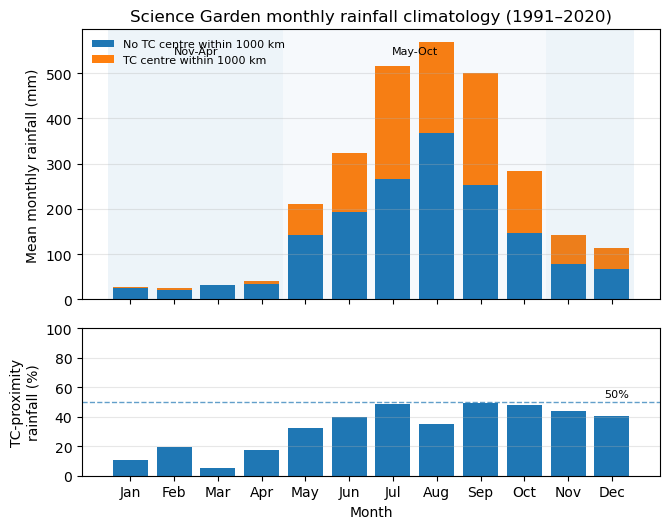

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_01_climatology_tc_fraction.png


In [14]:
FIGURE_01_CLIMATOLOGY_ONLY_PATH = FIGURE_DIR / "figure_01_climatology_tc_fraction.png"

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(6.8, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2]}
)

x = np.arange(len(monthly_climatology))

month_labels = monthly_climatology["month_label"]
nontc_vals = monthly_climatology["mean_nontc1000_rainfall_mm"]
tc_vals = monthly_climatology["mean_tc1000_rainfall_mm"]
fraction_vals = monthly_climatology["tc1000_fraction_percent"]

# -----------------------------
# Panel a: Stacked rainfall climatology
# -----------------------------
ax = axes[0]

ax.bar(
    x,
    nontc_vals,
    label="No TC centre within 1000 km"
)

ax.bar(
    x,
    tc_vals,
    bottom=nontc_vals,
    label="TC centre within 1000 km"
)

ax.set_ylabel("Mean monthly rainfall (mm)")
ax.set_title(f"Science Garden monthly rainfall climatology ({CLIM_START}–{CLIM_END})")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=8, loc="upper left")

# Optional season labels
ax.axvspan(-0.5, 3.5, alpha=0.08)
ax.axvspan(9.5, 11.5, alpha=0.08)
ax.axvspan(3.5, 9.5, alpha=0.04)

ax.text(
    1.5,
    ax.get_ylim()[1] * 0.94,
    DRY_SEASON_LABEL,
    ha="center",
    va="top",
    fontsize=8
)

ax.text(
    6.5,
    ax.get_ylim()[1] * 0.94,
    WET_SEASON_LABEL,
    ha="center",
    va="top",
    fontsize=8
)

# -----------------------------
# Panel b: TC-proximity rainfall fraction
# -----------------------------
ax = axes[1]

ax.bar(
    x,
    fraction_vals
)

ax.axhline(50, linewidth=1, linestyle="--", alpha=0.7)

ax.set_ylabel("TC-proximity\nrainfall (%)")
ax.set_xlabel("Month")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)

ax.text(
    11.4,
    52,
    "50%",
    ha="right",
    va="bottom",
    fontsize=8
)

plt.tight_layout()
plt.savefig(FIGURE_01_CLIMATOLOGY_ONLY_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_01_CLIMATOLOGY_ONLY_PATH}")